# What the Hybrid SIR-VAE Project Does

The first task is a parameter-recovery check: generate case curves with known parameters and determine whether VAE inference recovers those parameters under the same assumed epidemic and observation model. This check comes before testing interventions or applying the method to real data.

The report separates data generation, VAE inference, observed results, and explanations that still need to be tested.


## 1. Scientific question and estimated quantities

The input is a 120-day curve of **reported daily incident cases**. From that curve, the model estimates:

- $\beta>0$: transmission rate per day;
- $\alpha>0$: recovery rate per day, so $1/\alpha$ is the mean infectious duration in this SIR model;
- $\rho>0$: the reporting multiplier that converts daily new infections into the expected daily reported count: $\mu_t=\rho i_t$. For example, $\rho=0.10$ maps 100 new infections to 10 expected reports.

The scientific targets are $\beta$ and $\alpha$. The reporting multiplier $\rho$ is a nuisance parameter, but it must be inferred jointly with them because the observed curve contains only a fraction of the infections generated by the SIR model. Ignoring uncertainty in $\rho$ would make uncertainty in $\beta$ and $\alpha$ look smaller than it really is.

The output is not only one best value. For each outbreak, the encoder returns an approximate joint posterior distribution, from which posterior means and 90% credible intervals are calculated.

## 2. Data used in the current study

The current study uses simulated outbreaks rather than real outbreak data. Simulation is useful here because the generating values of $\beta$, $\alpha$, and $\rho$ are known and can be kept aside for evaluation.

| Item | Current setting |
|---|---|
| One sample | 120 consecutive daily reported case counts |
| Saved baseline: training / validation / test | 16,000 / 2,000 / 500 independently simulated outbreaks |
| Population and initial state | $N=100{,}000$, $I_0=20$ |
| Varying outbreak-level quantities | $\beta$, $\alpha$, $\rho$, and reporting noise |
| Observation model | negative binomial with mean $\mu_t=\rho\lambda_t$ and dispersion $k$ |

Here $\lambda_t$ is the SIR model's number of **new infections during day $t$**, not the number currently infectious $I_t$. The true simulated parameters are never supplied to the training loss; they are used only after training to assess recovery and calibration.

A second simulated dataset reduces transmission around day 55. It represents an intervention or behaviour change and tests robustness when a constant-rate SIR model is misspecified.
### What “the same model” means

For data generation, draw known parameters from the prior, solve the SIR model for daily incidence $i_t$, calculate $\mu_t=\rho i_t$, and draw $Y_t\sim\operatorname{NegBin}(\text{mean}=\mu_t,k=10)$.

For inference, the encoder uses the observed case curve to approximate the parameter posterior. Each parameter draw is passed through the decoder to obtain $i_t$ and then $\mu_t=\rho i_t$. The negative-binomial likelihood scores the observed counts using this mean. The generating parameter labels are used only for evaluation.

| Component | Data generator, baseline | Current saved VAE baseline |
|---|---|---|
| Physical parameter prior | Standard normal coordinates transformed to lognormal $\beta,\alpha,\rho$ | Same prior and transformation |
| SIR calculation | `sir_incidence`, constant $\beta,\alpha$ | Same function and fixed population/initial state |
| Reporting mean | $\mu_t=\rho i_t$ | Same scaling, after an additional neural correction to incidence |
| Negative binomial | Mean–dispersion form, fixed $k=10$ | Same form, learned global $k$ |
| Neural correction | None | Enabled, `nn_scale=0.3`, `residual_mode="obs"` |

Thus the saved baseline shares the core mechanism and observation family, but it is not a strictly identical full generative model. A strict matched-model control should disable the neural correction and hold $k=10$ fixed. Successful recovery means accurate estimates across held-out outbreaks and calibrated uncertainty; it does not require every noisy outbreak's posterior mean to equal its generating value exactly.

**Experiment provenance.** The saved checkpoint is `results_hybrid/sir_final2_model.pt`: seed 0, 16,000 training curves, 2,000 validation curves, 500 test curves, full-covariance encoder, IWAE with 5 samples, and no intervention. The workflow below has been relabelled to match this split. The separate runnable `Hybrid_SIR_VAE_report.ipynb` uses its own experiment settings; its outputs should not be attributed to this checkpoint without verification.


## 3. Study workflow

The observation step has two parts, in this order:

$$
\underbrace{i_t}_{\text{daily new infections}}
\;\xrightarrow{\;\times\rho\;}\;
\underbrace{\mu_t=\rho i_t}_{\text{expected daily reports}}
\;\xrightarrow{\;\text{negative-binomial sampling}\;}\;
\underbrace{Y_t}_{\text{observed daily reports}}.
$$

Here $i_t$ is the infection incidence denoted by $\lambda_t$ in the workflow figure and implementation. The multiplication computes a mean; the negative binomial adds observation variability around that mean.


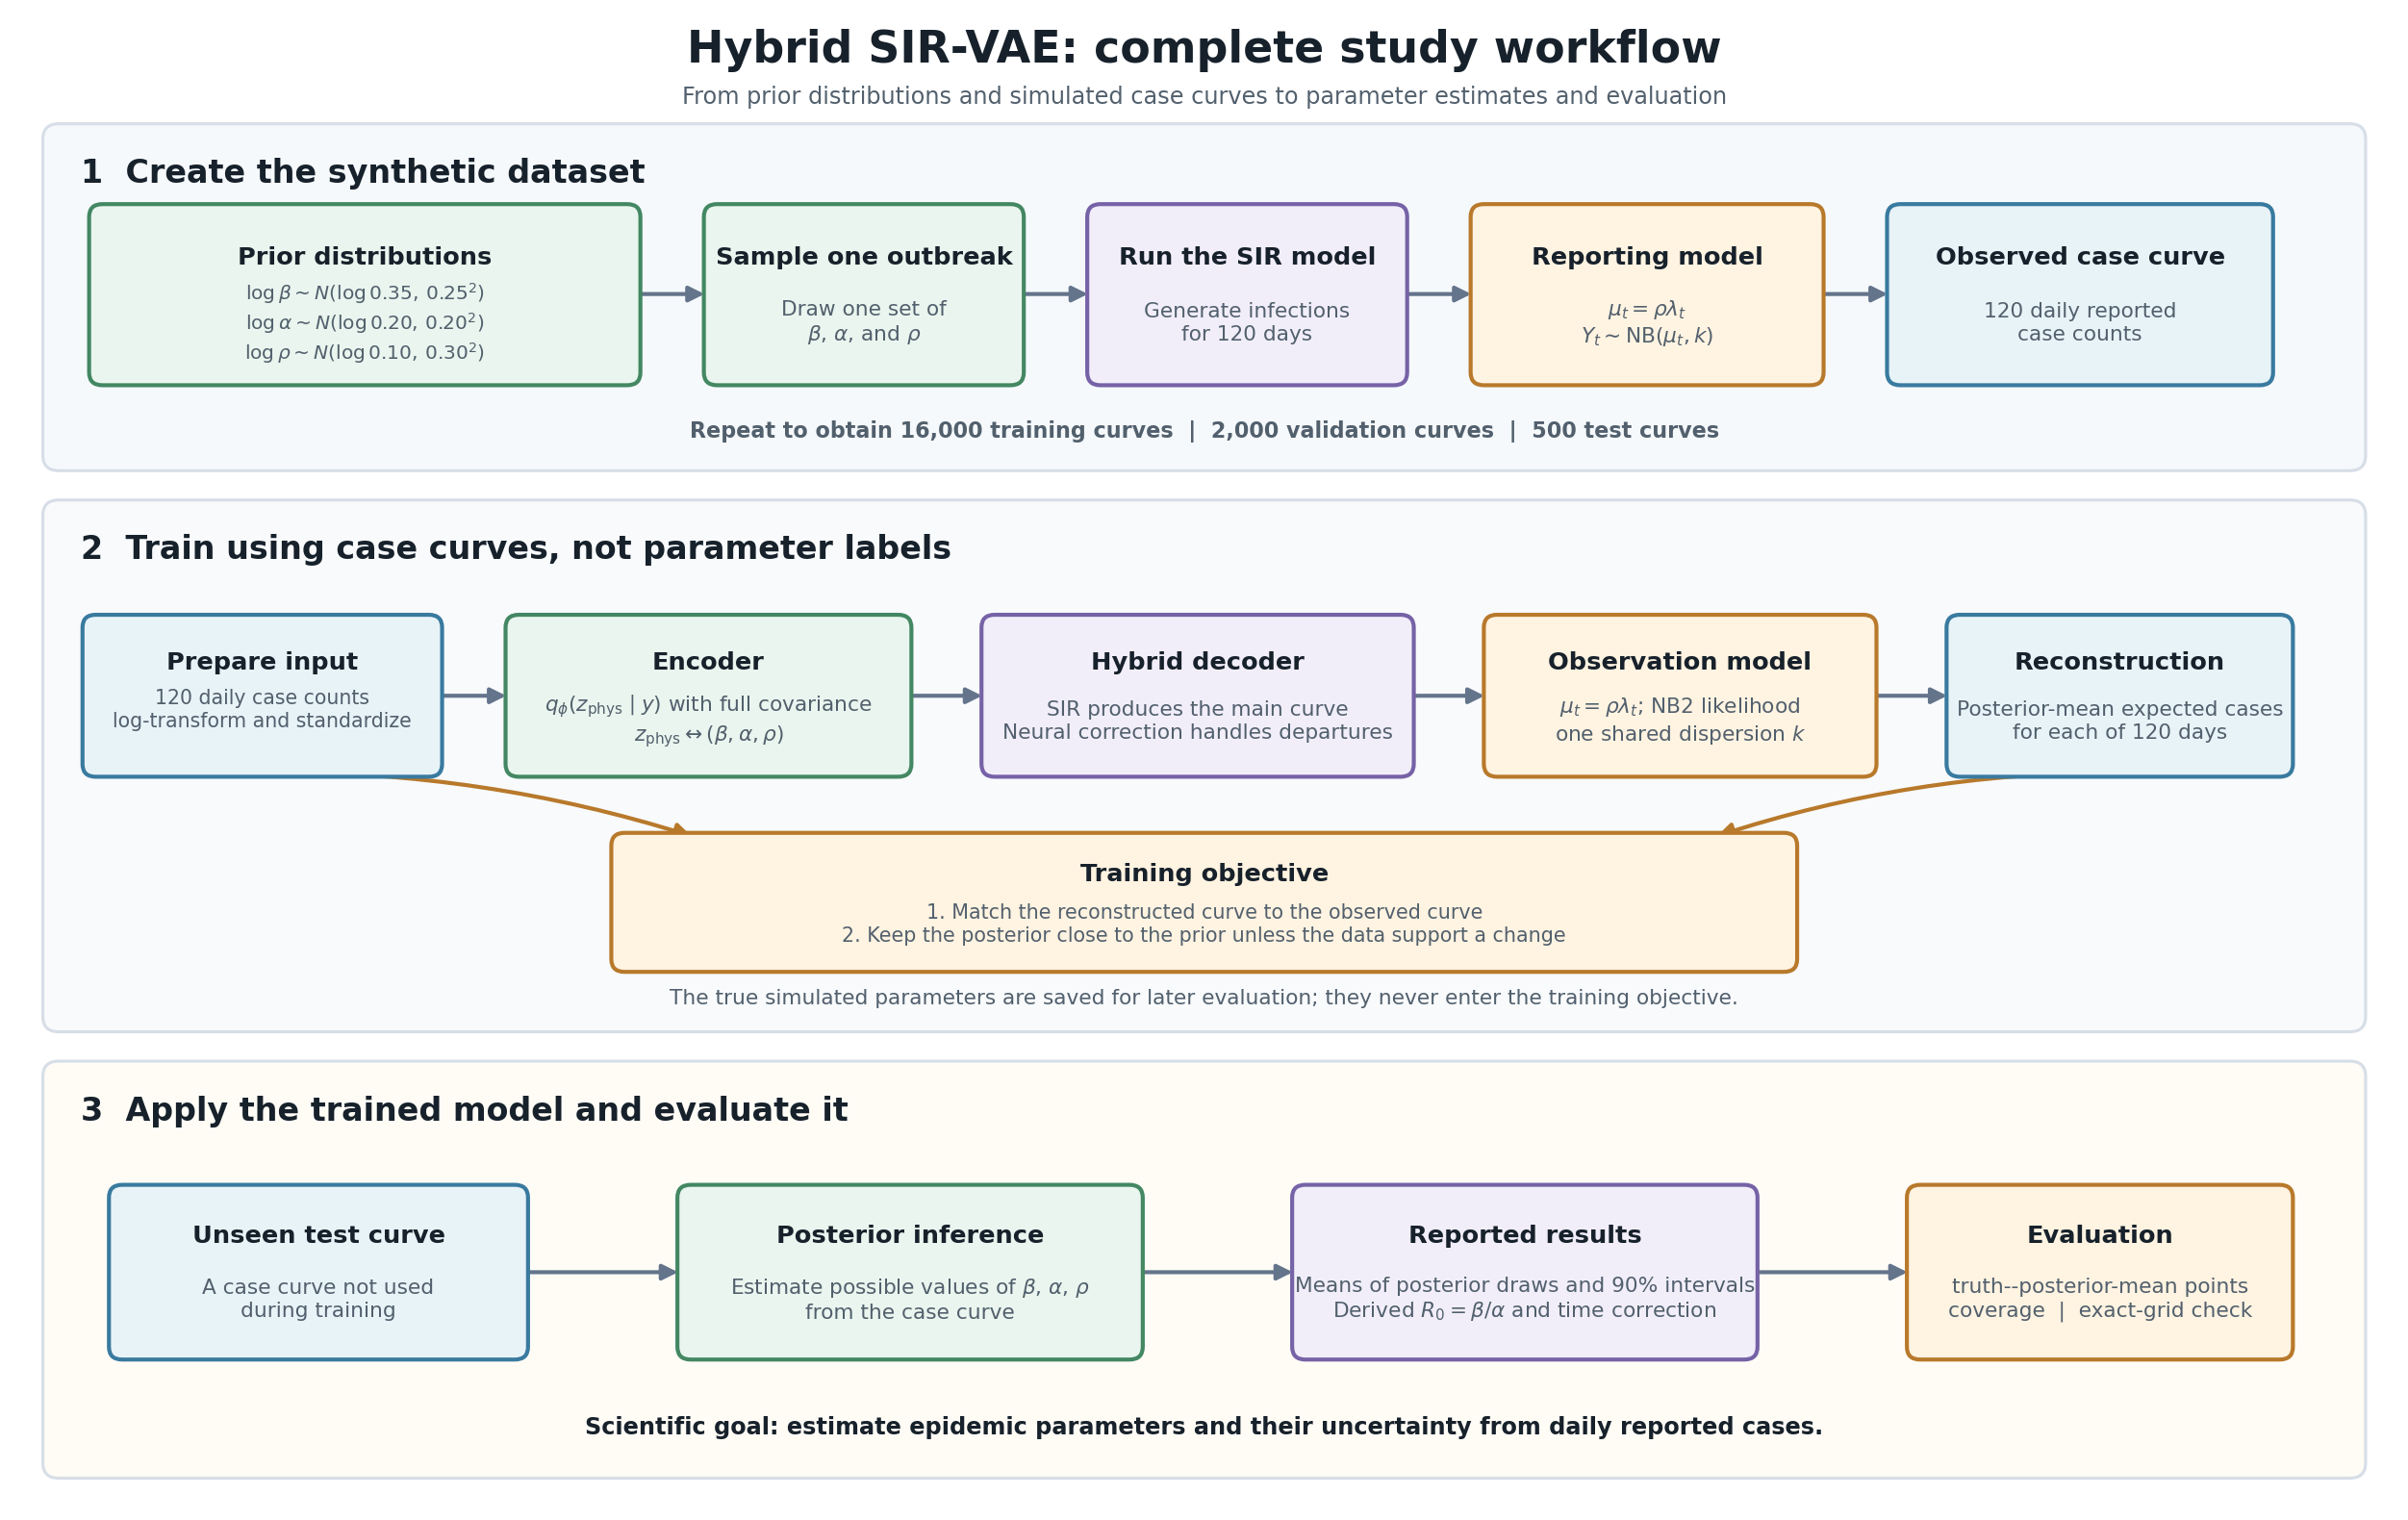

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(17, 11), dpi=150)
ax.set_xlim(0, 18)
ax.set_ylim(0, 11.7)
ax.axis("off")
fig.patch.set_facecolor("white")

C = {
    "ink": "#17212B",
    "muted": "#52606D",
    "line": "#64748B",
    "panel_line": "#D7DEE7",
    "data_panel": "#F5F9FC",
    "train_panel": "#F8FAFC",
    "test_panel": "#FFFCF6",
    "blue": "#E8F3F8",
    "blue_edge": "#397A9F",
    "green": "#E9F5EE",
    "green_edge": "#438763",
    "purple": "#F1EEFA",
    "purple_edge": "#7662A6",
    "orange": "#FFF3E1",
    "orange_edge": "#B8792B",
}

def add_panel(x, y, w, h, number, title, fill):
    shape = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.035,rounding_size=0.12",
        facecolor=fill,
        edgecolor=C["panel_line"],
        linewidth=1.5,
        zorder=0
    )
    ax.add_patch(shape)

    ax.text(
        x + 0.25, y + h - 0.35,
        f"{number}  {title}",
        ha="left", va="center",
        fontsize=16,
        fontweight="bold",
        color=C["ink"]
    )

def add_box(
    x, y, w, h, title, body,
    fill, edge, body_size=10.4
):
    shape = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.035,rounding_size=0.10",
        facecolor=fill,
        edgecolor=edge,
        linewidth=2,
        zorder=2
    )
    ax.add_patch(shape)

    ax.text(
        x + w / 2, y + h * 0.72,
        title,
        ha="center", va="center",
        fontsize=12.3,
        fontweight="bold",
        color=C["ink"],
        zorder=3
    )

    ax.text(
        x + w / 2, y + h * 0.34,
        body,
        ha="center", va="center",
        fontsize=body_size,
        color=C["muted"],
        linespacing=1.25,
        zorder=3
    )

def add_arrow(start, end, color=None, curve=0.0):
    shape = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=2,
        color=color or C["line"],
        connectionstyle=f"arc3,rad={curve}",
        shrinkA=2,
        shrinkB=2,
        zorder=1
    )
    ax.add_patch(shape)

# =========================================================
# Title
# =========================================================

ax.text(
    9, 11.42,
    "Hybrid SIR-VAE: complete study workflow",
    ha="center", va="center",
    fontsize=22,
    fontweight="bold",
    color=C["ink"]
)

ax.text(
    9, 11.05,
    "From prior distributions and simulated case curves "
    "to parameter estimates and evaluation",
    ha="center", va="center",
    fontsize=11.5,
    color=C["muted"]
)

# =========================================================
# 1. CREATE SYNTHETIC DATA
# =========================================================

add_panel(
    0.25, 8.15, 17.5, 2.65,
    "1",
    "Create the synthetic dataset",
    C["data_panel"]
)

add_box(
    0.60, 8.82, 4.10, 1.35,
    "Prior distributions",
    r"$\log\beta\sim N(\log 0.35,\,0.25^2)$"
    "\n"
    r"$\log\alpha\sim N(\log 0.20,\,0.20^2)$"
    "\n"
    r"$\log\rho\sim N(\log 0.10,\,0.30^2)$",
    C["green"],
    C["green_edge"],
    body_size=9.7
)

add_box(
    5.25, 8.82, 2.35, 1.35,
    "Sample one outbreak",
    "Draw one set of\n"
    r"$\beta$, $\alpha$, and $\rho$",
    C["green"],
    C["green_edge"]
)

add_box(
    8.15, 8.82, 2.35, 1.35,
    "Run the SIR model",
    "Generate infections\nfor 120 days",
    C["purple"],
    C["purple_edge"]
)

add_box(
    11.05, 8.82, 2.60, 1.35,
    "Reporting model",
    r"$\mu_t=\rho\lambda_t$"
    "\n"
    r"$Y_t\sim\mathrm{NB}(\mu_t,k)$",
    C["orange"],
    C["orange_edge"]
)

add_box(
    14.20, 8.82, 2.85, 1.35,
    "Observed case curve",
    "120 daily reported\ncase counts",
    C["blue"],
    C["blue_edge"]
)

add_arrow((4.70, 9.50), (5.25, 9.50))
add_arrow((7.60, 9.50), (8.15, 9.50))
add_arrow((10.50, 9.50), (11.05, 9.50))
add_arrow((13.65, 9.50), (14.20, 9.50))

ax.text(
    9, 8.43,
    "Repeat to obtain 16,000 training curves  |  "
    "2,000 validation curves  |  500 test curves",
    ha="center", va="center",
    fontsize=10.7,
    fontweight="bold",
    color=C["muted"]
)

# =========================================================
# 2. TRAIN THE MODEL
# =========================================================

add_panel(
    0.25, 3.75, 17.5, 4.10,
    "2",
    "Train using case curves, not parameter labels",
    C["train_panel"]
)

add_box(
    0.55, 5.75, 2.65, 1.20,
    "Prepare input",
    "120 daily case counts\n"
    "log-transform and standardize\n",
    C["blue"],
    C["blue_edge"],
    body_size=9.8
)

add_box(
    3.75, 5.75, 3.00, 1.20,
    "Encoder",
    r"$q_\phi(z_{\rm phys}\mid y)$ with full covariance"
    "\n"
    r"$z_{\rm phys}\leftrightarrow(\beta,\alpha,\rho)$",
    C["green"],
    C["green_edge"]
)

add_box(
    7.35, 5.75, 3.20, 1.20,
    "Hybrid decoder",
    "SIR produces the main curve\n"
    "Neural correction handles departures",
    C["purple"],
    C["purple_edge"]
)

add_box(
    11.15, 5.75, 2.90, 1.20,
    "Observation model",
    r"$\mu_t=\rho\lambda_t$; NB2 likelihood"
    "\n"
    r"one shared dispersion $k$",
    C["orange"],
    C["orange_edge"]
)

add_box(
    14.65, 5.75, 2.55, 1.20,
    "Reconstruction",
    "Posterior-mean expected cases\nfor each of 120 days",
    C["blue"],
    C["blue_edge"]
)

add_arrow((3.20, 6.35), (3.75, 6.35))
add_arrow((6.75, 6.35), (7.35, 6.35))
add_arrow((10.55, 6.35), (11.15, 6.35))
add_arrow((14.05, 6.35), (14.65, 6.35))

add_box(
    4.55, 4.22, 8.90, 1.02,
    "Training objective",
    "1. Match the reconstructed curve to the observed curve\n"
    "2. Keep the posterior close to the prior unless "
    "the data support a change",
    C["orange"],
    C["orange_edge"],
    body_size=9.9
)

add_arrow(
    (1.88, 5.75),
    (5.15, 5.24),
    color=C["orange_edge"],
    curve=-0.08
)

add_arrow(
    (15.93, 5.75),
    (12.85, 5.24),
    color=C["orange_edge"],
    curve=0.08
)

ax.text(
    9, 3.98,
    "The true simulated parameters are saved for later evaluation; "
    "they never enter the training objective.",
    ha="center", va="center",
    fontsize=10.4,
    color=C["muted"]
)

# =========================================================
# 3. OUTPUT AND EVALUATION
# =========================================================

add_panel(
    0.25, 0.25, 17.5, 3.20,
    "3",
    "Apply the trained model and evaluate it",
    C["test_panel"]
)

add_box(
    0.75, 1.18, 3.10, 1.30,
    "Unseen test curve",
    "A case curve not used\nduring training",
    C["blue"],
    C["blue_edge"]
)

add_box(
    5.05, 1.18, 3.45, 1.30,
    "Posterior inference",
    r"Estimate possible values of $\beta$, $\alpha$, $\rho$"
    "\nfrom the case curve",
    C["green"],
    C["green_edge"]
)

add_box(
    9.70, 1.18, 3.45, 1.30,
    "Reported results",
    "Means of posterior draws and 90% intervals\n"
    r"Derived $R_0=\beta/\alpha$ and time correction",
    C["purple"],
    C["purple_edge"]
)

add_box(
    14.35, 1.18, 2.85, 1.30,
    "Evaluation",
    "truth--posterior-mean points\n"
    "coverage  |  exact-grid check",
    C["orange"],
    C["orange_edge"]
)

add_arrow((3.85, 1.83), (5.05, 1.83))
add_arrow((8.50, 1.83), (9.70, 1.83))
add_arrow((13.15, 1.83), (14.35, 1.83))

ax.text(
    9, 0.62,
    "Scientific goal: estimate epidemic parameters and their "
    "uncertainty from daily reported cases.",
    ha="center", va="center",
    fontsize=11.5,
    fontweight="bold",
    color=C["ink"]
)

plt.subplots_adjust(
    left=0.015,
    right=0.985,
    top=0.97,
    bottom=0.03
)

plt.show()

## 4. What $Z$ means and what the encoder posterior is

The notation separates two kinds of latent variables:

$$Z=(Z_{\mathrm{phys}},Z_{\mathrm{res}}),\qquad Z_{\mathrm{phys}}=(Z_\beta,Z_\alpha,Z_\rho).$$

### Physical latent variables

The prior is $Z_{\mathrm{phys}}\sim\mathcal N(0,I_3)$. Its three standardized coordinates are mapped deterministically and one-to-one to physical parameters:

$$
\beta=\exp(\log 0.35+0.25Z_\beta),\qquad
\alpha=\exp(\log 0.20+0.20Z_\alpha),\qquad
\rho=\exp(\log 0.10+0.30Z_\rho).
$$

Thus, $Z_\beta=0$ means the prior-median transmission rate $0.35$ per day; it does **not** mean $\beta=0$. The same interpretation applies to the other coordinates. The lognormal transformation keeps all three physical quantities positive and makes the VAE prior on $Z$ a standard normal.

For an observed curve $y$, the encoder outputs

$$q_\phi(Z_{\mathrm{phys}}\mid y)=\mathcal N\!\left(m_\phi(y),L_\phi(y)L_\phi(y)^\top\right).$$

This is an **amortized variational approximation** to the Bayesian posterior $p(Z_{\mathrm{phys}}\mid y)$, not the exact posterior itself. “Amortized” means that one trained encoder supplies the posterior for every new curve in one forward pass. The full covariance is intentional: $\beta$ and $\alpha$ can trade off while preserving the early growth rate $\beta-\alpha$, so their posterior generally forms a tilted ridge. A diagonal Gaussian would miss this dependence and understate marginal uncertainty.

The posterior for $(\beta,\alpha,\rho)$ is the distribution induced by transforming draws from $q_\phi(Z_{\mathrm{phys}}\mid y)$. It is therefore better to transform many draws and summarize them than to transform only $m_\phi(y)$; because the transformation is nonlinear, $E[g(Z)]\neq g(E[Z])$ in general.

### Residual latent variables

$Z_{\mathrm{res}}$ is separate from $Z_{\mathrm{phys}}$. It has no epidemiological units and feeds a smooth neural correction that can represent departures from the constant-rate SIR mechanism. It is not part of the reported estimates of $\beta$, $\alpha$, or $\rho$. When the data follow the SIR model, the regularization encourages this correction to remain near zero.

## 5. From infections to reported cases: first the mean, then the noise

**Step 1 — Multiply daily new infections by $\rho$ to obtain the expected reported count.**

Let $i_t$ denote the model's number of new infections during day $t$, including any neural correction to the infection curve. This is the quantity written as $\lambda_t$ elsewhere in this report. It is different from the SIR state $I_t$, which counts people who are currently infectious.

$$\boxed{\mu_t=\rho\times i_t}$$

$\rho$ is the reporting multiplier: it determines how many cases are expected to be reported per infection. For example, if $i_t=100$ and $\rho=0.10$, the expected reported count is $\mu_t=10$. This multiplication is deterministic once $\rho$ and $i_t$ are given. Here “mean” means the expected count for that particular day, not an average of infections across days.

**Step 2 — Use that mean in a negative-binomial observation model.**

$$\boxed{Y_t\mid i_t,\rho,k\sim\operatorname{NegBin}\bigl(\text{mean}=\mu_t,\;\text{dispersion}=k\bigr)}$$

The observed count $Y_t$ fluctuates around $\mu_t$. In the example above, its expected value is 10, but an individual observation need not equal 10. The mean and variance are

$$E(Y_t\mid i_t,\rho,k)=\mu_t,\qquad
\operatorname{Var}(Y_t\mid i_t,\rho,k)=\mu_t+\frac{\mu_t^2}{k}.$$

Thus **$\rho$ sets the expected reporting level**, while **$k$ controls the variability around that level**. For example, $\mu_t=10$ and $k=10$ give mean 10 and variance 20. Smaller $k$ produces more variability for the same mean.

During simulation, we sample $Y_t$ from this distribution. During training, we evaluate the probability of the observed $y_t$ under the same distribution. Both use the mean calculated in Step 1.

### Assumptions and implementation details

$\rho$ is inferred separately for each outbreak and is constant over its 120-day window. It acts on the infection curve after the SIR calculation; it does not enter the SIR differential equations. The current model has no reporting delay. The dispersion $k$ is one positive parameter learned across the training dataset.

The current prior is $\log\rho\sim\mathcal N(\log 0.10,0.30^2)$. It makes $\rho$ positive but does not constrain it below 1, so “reporting multiplier” is the precise term for this implementation. A strict reporting-probability interpretation would require a prior supported on $(0,1)$.

The negative binomial uses the mean–dispersion (NB2) convention shown above. In the existing PyTorch implementation, the two steps correspond to:

```python
incidence = sir_incidence(beta, alpha)       # i_t: daily new infections
mean_reported = rho.unsqueeze(1) * incidence # Step 1: mu_t = rho * i_t
observation_dist = torch.distributions.NegativeBinomial(
    total_count=k,
    logits=torch.log(mean_reported.clamp(min=1e-6)) - torch.log(k),
)                                           # Step 2: NB with this mean
```

Here `k` is a positive tensor; the small lower bound on the mean is the existing numerical safeguard for taking logarithms. Any neural correction is applied to the incidence before calculating `mean_reported`.


## 6. Posterior summaries, reconstruction, and evaluation

For outbreak $i$, draw $Z_{\mathrm{phys},i}^{(1)},\ldots,Z_{\mathrm{phys},i}^{(M)}$ from the encoder posterior and transform each draw to $\theta_i^{(m)}=(\beta_i^{(m)},\alpha_i^{(m)},\rho_i^{(m)})$. The reported point estimate is

$$\widehat\theta_i=\frac{1}{M}\sum_{m=1}^M\theta_i^{(m)},$$

and the 90% credible interval uses the 5th and 95th percentiles of those draws.

This explains why the parameter-accuracy figure is **point-to-point**: each test outbreak contributes one pair $(\theta_i^{\mathrm{true}},\widehat\theta_i)$. There is one estimated point because the posterior has been summarized by its mean for that scatter plot, not because the posterior itself is a point mass. The credible intervals and coverage calculation retain the posterior uncertainty.

The reconstructed curve is summarized similarly. At each day $t$, the decoder mean is averaged across posterior draws,

$$\widehat\mu_{it}=\frac{1}{M}\sum_{m=1}^M\rho_i^{(m)}\lambda_{it}^{(m)}.$$

Plotting the 120 values $\widehat\mu_{it}$ produces a day-by-day posterior-mean curve. This is an expected reported count, not an additional noisy negative-binomial realization. A full posterior-predictive band would also include both parameter uncertainty and negative-binomial observation noise.

Evaluation uses held-out simulated outbreaks:

- **Point accuracy:** RMSE and correlation between truth and posterior mean;
- **Calibration:** whether the 90% credible interval contains the truth about 90% of the time;
- **Posterior validation:** comparison of $q_\phi(Z_{\mathrm{phys}}\mid y)$ with a finely enumerated grid posterior under the same prior and likelihood;
- **Robustness:** comparison with a mechanism-only model when transmission changes over time.

The grid posterior is called “exact” only relative to the stated three-parameter discretized model and after checking that further grid refinement does not change the result. It is a benchmark for the VAE approximation, not a claim that the epidemiological model is exactly true.

## 7. Current results and the next diagnostic step

The existing repository summary records held-out truth-versus-posterior-mean correlations for the saved baseline:

| Parameter | Recorded correlation |
|---|---:|
| $\beta$ | 0.968 |
| $\alpha$ | 0.771 |
| $\rho$ | 0.946 |
| $R_0=\beta/\alpha$ | 0.964 |

These are previously recorded results, not a new evaluation in this revision. They show weaker point recovery for $\alpha$. Correlation alone does not establish accuracy or calibration: per-parameter bias, RMSE, interval width, and 90% coverage must also be reported. The README's overall coverage figure of 89% does not establish 90% coverage for every parameter.

Earlier comparisons suggested that VAE intervals can be narrower than grid-based intervals. The cause is **not yet established by a strictly matched and numerically converged comparison**. In particular, the existing grid script omits the VAE's neural correction and uses learned $k$, so its posterior is not automatically the posterior of the full hybrid model. Finite grids also require resolution and range checks.

### Diagnostic sequence after clarifying the model

1. **Check exact agreement at given parameters.** Disable neural correction, fix $k=10$, and compare generator and decoder incidence, reported means, and likelihoods at identical parameter values. Check preprocessing and test-set reconstruction as well.
2. **Establish a numerical reference.** On the same held-out curves and under the same fixed model, compute a grid posterior and check convergence as grid resolution and range increase. Report its parameter recovery and interval coverage.
3. **Compare VAE inference with that reference.** If the reference recovers parameters but the VAE does not, investigate training, the variational approximation, and encoder errors. If both are uncertain, investigate how much information the observations contain before concluding that identifiability limits recovery.
4. **Add complexity only after the control works.** Reintroduce learned dispersion and neural correction separately, and only then study intervention data.

Parameter confounding is a possible explanation, not a demonstrated ceiling on $\alpha$ recovery. No theoretical correlation ceiling of 0.77 is claimed. This revision clarifies the experiment and the evidence required; it does not claim that retraining or the full diagnostic sequence has been completed.
